# EPSP ratio comparison with Egger et al. 1999 dataset
## L2/3-PC to L2/3-PC

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference == "Egger et al. 1999"]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
8,egg99_01,L23PC,L23PC,SSC (barrel),rat,P12 - P14,20.0,10,5,10,10,1.299,0.082,12,Egger et al. 1999,Nothing.,0.284056
9,egg99_02,L4SS,L4SS,SSC (barrel),rat,P12 - P14,1.0,10,5,10,10,0.816,0.060,4,Egger et al. 1999,Nothing.,0.120000
10,egg99_03,L4SS,L4SS,SSC (barrel),rat,P12 - P14,10.0,10,5,10,10,0.595,0.060,5,Egger et al. 1999,Nothing.,0.134164
11,egg99_04,L4SS,L4SS,SSC (barrel),rat,P12 - P14,20.0,10,5,10,10,0.672,0.059,21,Egger et al. 1999,Nothing.,0.270372
12,egg99_05,L4SS,L4SS,SSC (barrel),rat,P12 - P14,50.0,10,5,10,10,0.966,0.066,4,Egger et al. 1999,Nothing.,0.132000


In [2]:
# Load Egger et al. 1999 data (L23PC to L23PC)
insilico_exp, insilico_out, insilico = load_insilico('data/insilico/egger_1999/L23PC_L23PC.csv')

Found outliers in data/insilico/egger_1999/L23PC_L23PC.csv:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
43,118951,125043,1.0,10.0,19.889551,0.006771
243,118951,125043,20.0,10.0,57.708128,0.004279


Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
40,120629,123878,1.0,10.0,1.674275,0.596986
45,26243,13997,1.0,10.0,1.497930,2.284818
300,16903,11518,50.0,10.0,0.462295,2.549889
60,18174,11590,1.0,10.0,1.018443,1.421532
272,124911,7194,20.0,10.0,1.792572,1.109485


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,1.0,10.0,1.623606,1.247267,0.125355,99
1,10.0,10.0,1.866930,1.979977,0.197998,100
2,20.0,10.0,1.780200,1.223373,0.122954,99
3,50.0,10.0,2.133908,3.030018,0.303002,100


t-test results for frequency_train = 20.000000: s = 3.256, p = 0.002


Text(0.5, 1.0, '$\\Delta t$ = 10 ms')

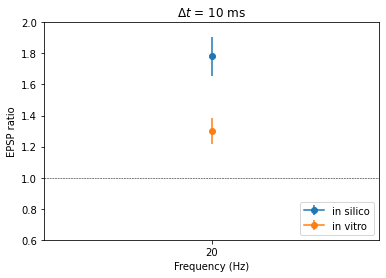

In [3]:
# Plot LTP freq
sel_invitro = invitro[invitro.pre_mtype=='L23PC']
sel_insilico = insilico[(insilico.dt_train==10) & (insilico.frequency_train==20)]

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', offset=False)

if pubstyle:
    fig.set_size_inches(0.8, 1.37795, forward=True)
ax.xaxis.set_major_locator(plt.FixedLocator([20]))
ax.legend(loc=4)
ax.set_ylim(0.6, 2)
ax.set_title(r'$\Delta t$ = 10 ms')

#fig.savefig('l23_l23_ltp.svg')

Model fit: 1.52 (+/- 0.04) x ^ -0.49 (+/- 0.06)


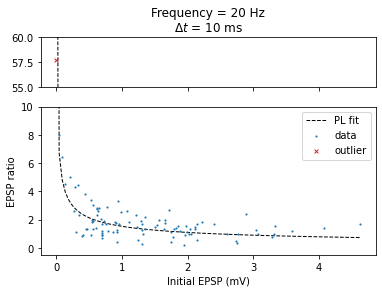

In [4]:
sel_in = insilico_exp[(insilico_exp.dt_train==10) & (insilico_exp.frequency_train==20)]
sel_out = insilico_out[(insilico_out.dt_train==10) & (insilico_out.frequency_train==20)]
sel = pd.concat([sel_in, sel_out])

popt, perr = fit_powerlaw(sel.epsp_before, sel.epsp_ratio)
print('Model fit: %.2f (+/- %.2f) x ^ %.2f (+/- %.2f)' % (popt[0], perr[0], popt[1], perr[1]))
x = np.linspace(0.0001, np.max(sel_in.epsp_before), 100)

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Plot data twice
def plot_data(ax):
    ax.scatter(sel_in.epsp_before, sel_in.epsp_ratio, s=5, alpha=1, marker='.', c='C0', label='data')
    ax.scatter(sel_out.epsp_before, sel_out.epsp_ratio, s=15, lw=1, alpha=1, marker='x', c='C3', label='outlier')
    ax.plot(x, powerlaw(x, *popt), lw=1, c='k', ls='dashed', label='PL fit', zorder=-1)
plot_data(ax_top)
plot_data(ax_bottom)

# Set appropriate axis limits
ax_top.set_ylim(55, 60)
ax_bottom.set_ylim(-0.5, 10)
assert sel_in.epsp_ratio.max() < 60
assert sel_in.epsp_ratio.min() > -0.5
assert sel_out.epsp_ratio.max() < 60
assert sel_out.epsp_ratio.min() > -0.5

# Finalize plot
ax_bottom.legend()
ax_top.set_title('Frequency = 20 Hz\n' + r'$\Delta t$ = 10 ms')
ax_bottom.set_ylabel('EPSP ratio')
ax_bottom.set_xlabel('Initial EPSP (mV)')
if pubstyle:
    ax_top.spines['bottom'].set_visible(False)
    fig.set_size_inches(1.16535, 1.37795, forward=True)
#fig.savefig('l23_l23_powerlaw.svg')

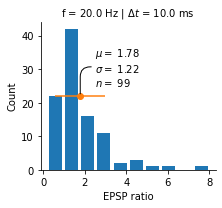

In [5]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"})
insilico_plot = insilico_plot[insilico_plot.f == 20]

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l23_l23_egg99_hist.png", dpi=300)

## L4-SSC to L4-SSC

In [6]:
# Load Egger et al. 1999 data (L4SSC to L4SSC)
insilico_exp, insilico_out, insilico = load_insilico('data/insilico/egger_1999/L4SSC_L4SSC.csv')

No outliers in data/insilico/egger_1999/L4SSC_L4SSC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
44,110202,111628,1.0,10.0,1.800045,0.423156
110,109741,109744,10.0,10.0,1.021146,1.271505
78,110463,109665,1.0,10.0,0.843036,3.648189
181,111611,110226,10.0,10.0,1.301351,2.329105
285,110512,109650,20.0,10.0,0.781972,3.317196


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,1.0,10.0,0.707300,0.299241,0.030075,99
1,10.0,10.0,0.882760,0.294365,0.029585,99
2,20.0,10.0,1.003873,0.235711,0.023690,99
3,50.0,10.0,1.050283,0.235808,0.023700,99


t-test results for frequency_train = 1.000000: s = -1.620, p = 0.170
t-test results for frequency_train = 10.000000: s = 4.302, p = 0.005
t-test results for frequency_train = 20.000000: s = 5.220, p = 0.000
t-test results for frequency_train = 50.000000: s = 1.202, p = 0.299


Text(0.5, 1.0, '$\\Delta t$ = 10 ms')

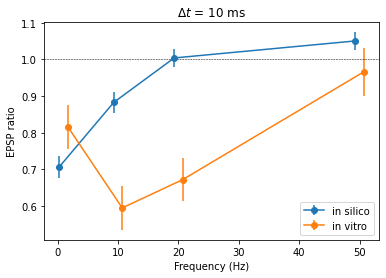

In [7]:
# Plot LTP freq
sel_invitro = invitro[invitro.pre_mtype=='L4SS']
sel_insilico = insilico[insilico.dt_train==10]

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
if pubstyle:
    fig.set_size_inches(2.16535, 1.37795, forward=True)
ax.set_title(u'$\Delta t$ = 10 ms')
#fig.savefig('l4_l4_ltd.svg')

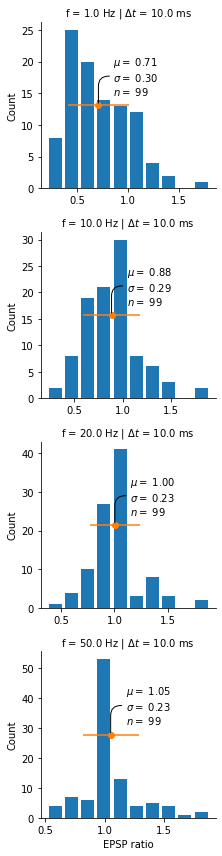

In [8]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity and drop the outlier connection
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"}).dropna()

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l4_l4_egg99_hist.png", dpi=300)